# Projection presets and one-call publication maps

A lon/lat field drawn on a flat grid distorts area badly at high latitudes. cleopatra can reproject an
`ArrayGlyph` onto an **orthographic globe** (or leave it flat) with a single `projection=` keyword, and it can
pick a professional ECMWF-style preset by GRIB shortName. This notebook covers:

- `projection="globe"` / `"flat"` on [`ArrayGlyph`](../../../src/cleopatra/array_glyph.py);
- selecting a vendored style with [`style_for_parameter`](../../../src/cleopatra/colors.py);
- unit-aware labels and [`convert_units`](../../../src/cleopatra/colors.py);
- the one-call [`publication_map`](../../../src/cleopatra/templates.py) composer.

The globe path reprojects with `pyproj`, shipped in the `cleopatra[tiles]` extra.

## Setup

We reuse the European 2 m temperature field. The projection path needs **1-D lon/lat coordinate vectors** (not just an extent), so we build them from the field's extent and shape.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np

from cleopatra.array_glyph import ArrayGlyph
from cleopatra.templates import publication_map
from cleopatra.colors import style_for_parameter, convert_units

DATA = Path("../../../examples/data")
t2m = np.load(DATA / "europe_t2m.npz")
temperature = t2m["celsius"][0]
west, east, south, north = t2m["extent"]
n_lat, n_lon = temperature.shape
lon = np.linspace(west, east, n_lon)
lat = np.linspace(north, south, n_lat)   # north-up array -> descending latitudes
lon.shape, lat.shape

((164,), (111,))

## Flat projection

`projection="flat"` keeps the field in lon/lat but routes through the projection machinery, so it composes with the globe path below. It needs no `pyproj`.

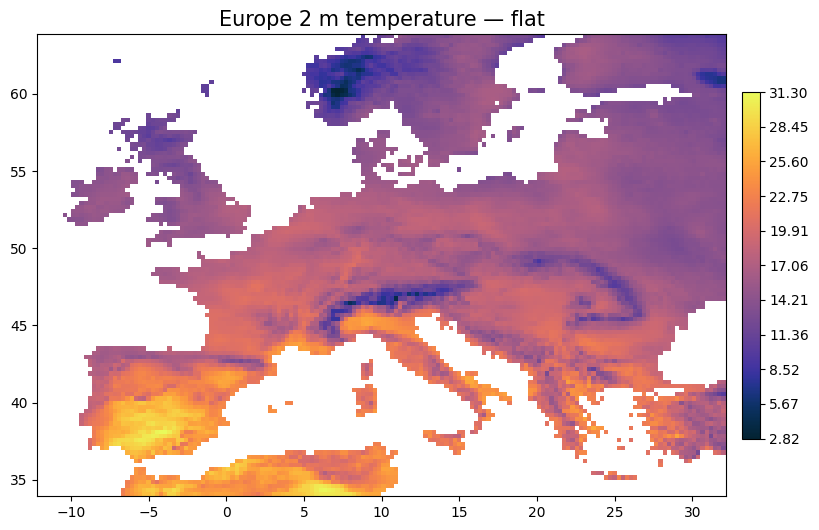

In [2]:
glyph = ArrayGlyph(temperature, coords=(lon, lat), cmap="cmocean:thermal", projection="flat")
fig, ax = glyph.plot(title="Europe 2 m temperature — flat")

## Orthographic globe

Switch to `projection="globe"` and the same field is reprojected onto a sphere, with the visible-hemisphere boundary and a graticule drawn automatically. Cells on the far side of the Earth are masked away.

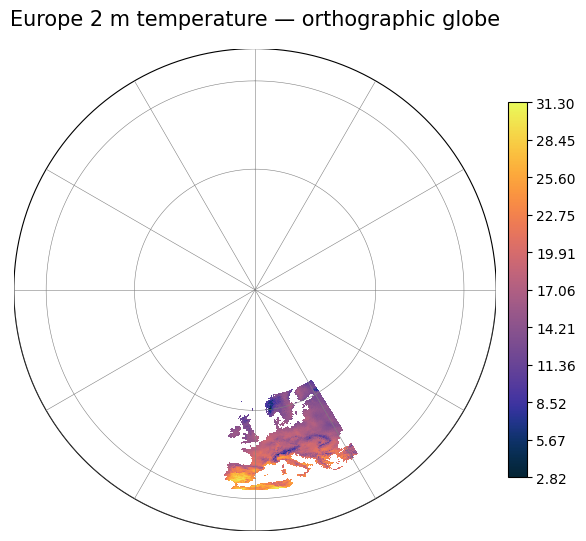

In [3]:
glyph = ArrayGlyph(temperature, coords=(lon, lat), cmap="cmocean:thermal", projection="globe")
fig, ax = glyph.plot(title="Europe 2 m temperature — orthographic globe")

The disc, meridians and parallels come from cleopatra's own orthographic maths (no cartopy dependency). Europe now sits on a curved surface with honest area near the pole.

## Picking a preset by parameter

cleopatra vendors ECMWF-style presets keyed by descriptive name. If you know a field's GRIB **shortName**,
`style_for_parameter` maps it to the matching preset — `"2t"` → `"temperature_2m"`. That preset renders the
familiar discrete `Spectral_r` temperature banding and labels its colour bar with the declared unit.

2t -> temperature_2m


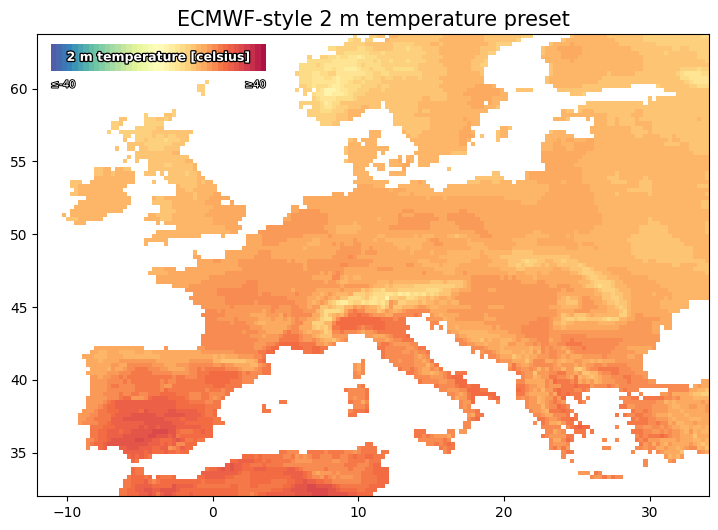

In [4]:
preset = style_for_parameter("2t")
print("2t ->", preset)
glyph = ArrayGlyph(temperature, extent=[west, east, south, north], style=preset)
fig, ax = glyph.plot(title="ECMWF-style 2 m temperature preset")

Notice the legend reads `2 m temperature [celsius]` — the unit is baked into the preset. cleopatra does not silently convert your data, so if your field were in Kelvin you would convert it first with `convert_units`.

In [5]:
kelvin = temperature + 273.15
back_to_celsius = convert_units(kelvin, "K", "celsius")
print("max |round-trip error| =", float(np.max(np.abs(back_to_celsius - temperature))))

max |round-trip error| = nan


## One call: `publication_map`

`publication_map` composes a styled field and a title block in a single call — the fastest way to a presentable figure.

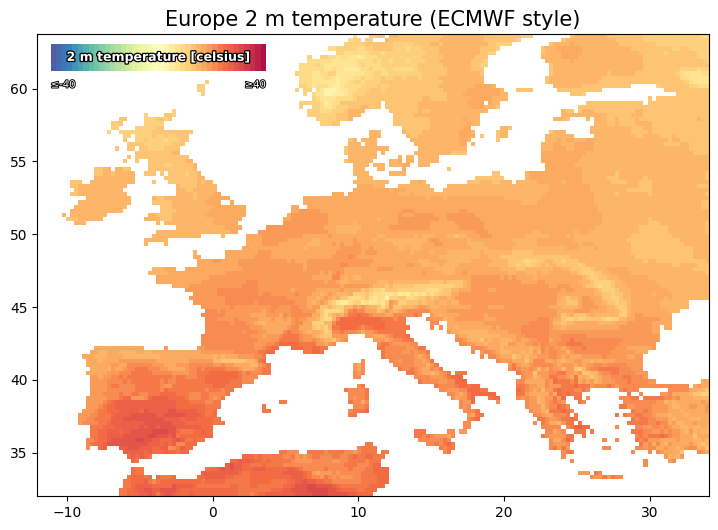

In [6]:
fig, ax = publication_map(
    temperature,
    extent=[west, east, south, north],
    style="temperature_2m",
    title="Europe 2 m temperature (ECMWF style)",
)

## Takeaway

- `projection="globe"` / `"flat"` reproject an `ArrayGlyph` given 1-D lon/lat `coords` (globe needs `[tiles]`).
- `style_for_parameter("2t")` selects the vendored `temperature_2m` preset; its label carries the declared unit.
- `convert_units` converts K/°C/°F on demand — cleopatra never mutates your data silently.
- `publication_map` bundles style + title (+ optional relief) into one call.

See the [scientific-colormaps notebook](../scientific_colormaps/scientific_colormaps_examples.ipynb) for the
colour side.